In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

## 1- VERİYİ YÜKLE
url = "https://docs.google.com/spreadsheets/d/1Woh-A5oTJ715ivgIsu6NCkdav_k46iqr/export?format=csv"
df = pd.read_csv(url)
print(f"Toplam veri boyutu: {len(df)}")

In [ ]:
# 2- Model yükleme
def load_model(repo):
    #HuggingFace'den tokenizer ve modeli yükleme
    tok = AutoTokenizer.from_pretrained(repo)
    model = AutoModel.from_pretrained(repo)
    return tok, model

models = {
    "e5": load_model("intfloat/multilingual-e5-large-instruct"),
    "cosmosE5": load_model("ytu-ce-cosmos/turkish-e5-large"),
    "jina": load_model("jinaai/jina-embeddings-v3")
}

In [4]:
# 3-  Metinleri vektör haline getirme
def embed(texts, tokenizer, model, batch_size=64, device="cuda", prefix=None):
    model = model.to(device).half().eval()

    all_embeddings = []

    # metinleri batch’ler halinde işle
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        if prefix is not None:
          batch_texts = [f"{prefix}: {t}" for t in batch_texts]

        # tokenizasyon
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad(), torch.cuda.amp.autocast():
            outputs = model(**inputs)
            last_hidden = outputs.last_hidden_state

            # mean pooling: token boyutu boyunca ortalama alarak tek vektöre indirger
            batch_embeddings = last_hidden.mean(dim=1)

        # np dizisine dönüştür
        all_embeddings.append(batch_embeddings.cpu().numpy())

    # gpu temizle
    model.cpu()
    torch.cuda.empty_cache()

    # tüm batchleri birleştir
    return np.vstack(all_embeddings)

# A) Sorudan Cevaba- Top1 ve Top 5 Başarı hesaplamaları
# 1-Rastgele 1000 örnek seç
sample = df.sample(1000, random_state=42).reset_index(drop=True)
questions = sample["Soru"].tolist()
answers_g4 = sample["gpt4o cevabı"].tolist()
answers_ds = sample["deepseek cevabı"].tolist()
labels = sample["Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)"].astype(int).values

# 2- Seçilen örnekler için her modelle embedding hesapla
embed_q = {}
embed_g4 = {}
embed_ds = {}

for name, (tok, model) in models.items():
  if name == "jina":
    embed_q[name] = embed(questions, tok, model)
    embed_g4[name] = embed(answers_g4, tok, model)
    embed_ds[name] = embed(answers_ds, tok, model)
  else:
    embed_q[name] = embed(questions, tok, model, prefix="query")
    embed_g4[name] = embed(answers_g4, tok, model, prefix="passage")
    embed_ds[name] = embed(answers_ds, tok, model, prefix="passage")

<ipython-input-4-619a5ad29b44>:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


In [5]:
# 3- Benzerlik matrislerini çıkar, top1-5 başarılarını ve kolerasyonları hesapla
results = []
corr_results = []
example_data = []

for name in models:
    # gpt ve deepseek için ayrı ayrı benzerlik hesapla
    sim_g4 = cosine_similarity(embed_q[name], embed_g4[name])
    sim_ds = cosine_similarity(embed_q[name], embed_ds[name])

    for sim_matrix, label in [(sim_g4, "gpt4o"), (sim_ds, "deepseek")]:
        n = sim_matrix.shape[0]
        # Top1: en yüksek benzerlikteki cevap doğru mu kontrol et
        top1_preds = np.argmax(sim_matrix, axis=1)
        top1_acc = np.mean(top1_preds == np.arange(n))

        # Top5: gerçek cevap ilk 5 içinde mi?
        top5_preds = np.argsort(-sim_matrix, axis=1)[:, :5]
        top5_acc = np.mean([i in top5_preds[i] for i in range(n)])

        results.append({
            "model": name,
            "method": label,
            "top1": top1_acc,
            "top5": top5_acc
        })

        # Tekil örnekler için top1-5 verilerini kaydet.
        random_indices = np.random.choice(len(sample), 3, replace=False)
        for idx in random_indices:
            top1_success = 'Evet' if top1_preds[idx] == idx else 'Hayır'
            top5_success = 'Evet' if idx in top5_preds[idx] else 'Hayır'
            true_label = labels[idx]
            closest_answer = top1_preds[idx]
            example_data.append({
                "Model": name,
                "Yöntem": label,
                "Soru İndeksi": idx,
                "Top1 Başarısı": top1_success,
                "Top5 Başarısı": top5_success,
                "Gerçek Etiket": true_label,
                "En Benzer Cevap İndeksi": closest_answer,
                "Tahmini Etiket": labels[closest_answer]
            })

        # Spearman kolerasyon hesapları
        top1_vec = (top1_preds == np.arange(n)).astype(int)
        top5_vec = np.array([j in top5_preds[j] for j in range(n)]).astype(int)
        rho1, p1 = st.spearmanr(top1_vec, labels)
        rho5, p5 = st.spearmanr(top5_vec, labels)
        corr_results.append({
            "model": name,
            "method": label,
            "top1_rho": rho1,
            "top1_p": p1,
            "top5_rho": rho5,
            "top5_p": p5
        })


Top1 ve Top5 Başarıları:
      model    method   top1   top5
0        e5     gpt4o  0.606  0.784
1        e5  deepseek  0.542  0.698
2  cosmosE5     gpt4o  0.535  0.734
3  cosmosE5  deepseek  0.474  0.643
4      jina     gpt4o  0.885  0.975
5      jina  deepseek  0.837  0.951

Korelasyon Sonuçları:
      model    method  top1_rho    top1_p  top5_rho    top5_p
0        e5     gpt4o  0.013386  0.672453 -0.011870  0.707740
1        e5  deepseek  0.031995  0.312127  0.037704  0.233558
2  cosmosE5     gpt4o  0.012682  0.688745  0.007797  0.805475
3  cosmosE5  deepseek  0.030988  0.327607  0.040877  0.196507
4      jina     gpt4o  0.000405  0.989800 -0.016662  0.598701
5      jina  deepseek -0.000968  0.975617 -0.002731  0.931268

Örnek Bazında Analiz Tablosu:
   Model   Yöntem  Soru İndeksi Top1 Başarısı Top5 Başarısı  Gerçek Etiket  En Benzer Cevap İndeksi  Tahmini Etiket
      e5    gpt4o            87          Evet          Evet              1                       87               1
  

<ipython-input-6-098893b0c943>:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Method")


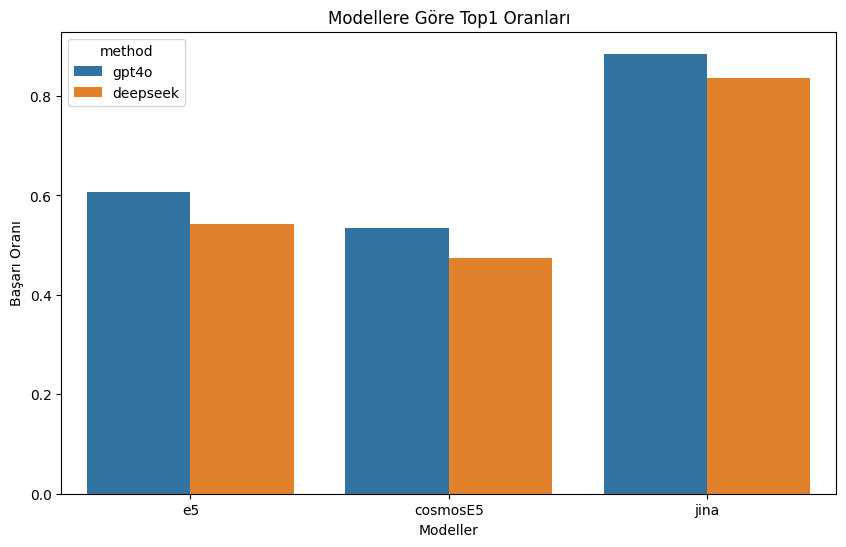

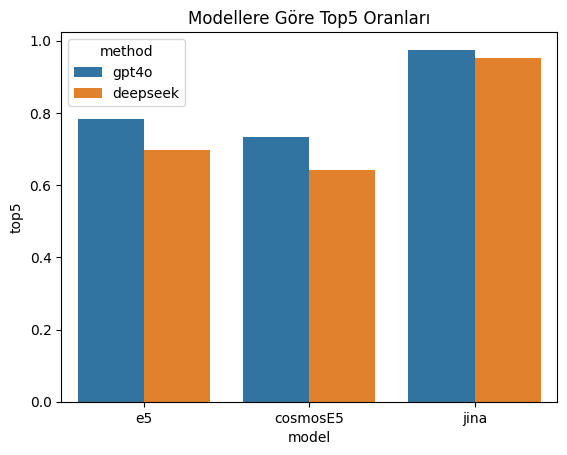

In [6]:
# 4-Kaydedilen sonuçları ekrana bastır ve grafik çıkart.
res_df = pd.DataFrame(results)
corr_df = pd.DataFrame(corr_results)
example_df = pd.DataFrame(example_data)
print("\nTop1 ve Top5 Başarıları:")
print(res_df)
print("\nKorelasyon Sonuçları:")
print(corr_df)
print("\nÖrnek Bazında Analiz Tablosu:")
print(example_df.to_string(index=False))

# Görselleştirme: Top1 ve Top5 başarıları
plt.figure(figsize=(10, 6))
plt.title("Modellere Göre Top1 Oranları")
plt.xlabel("Modeller")
plt.ylabel("Başarı Oranı")
plt.legend(title="Method")
sns.barplot(data=res_df, x="model", y="top1", hue="method")
plt.figure()
plt.savefig("top1_basari.png")
print()
plt.title("Modellere Göre Top5 Oranları")
sns.barplot(data=res_df, x="model", y="top5", hue="method")
plt.savefig("top5_basari.png")
plt.show()


In [7]:
# B) Hangisi iyi sınıflandırma
all_questions = df["Soru"].tolist()
all_answers_g4 = df["gpt4o cevabı"].tolist()
all_answers_ds = df["deepseek cevabı"].tolist()
all_labels = df["Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)"].astype(int).values - 1  # 0-3 için

all_embed_q = {}
all_embed_g4 = {}
all_embed_ds = {}

for name, (tok, model) in models.items():
  if name == "jina":
    all_embed_q[name] = embed(all_questions, tok, model)
    all_embed_g4[name] = embed(all_answers_g4, tok, model)
    all_embed_ds[name] = embed(all_answers_ds, tok, model)
  else:
    all_embed_q[name] = embed(all_questions, tok, model, prefix="query")
    all_embed_g4[name] = embed(all_answers_g4, tok, model, prefix="passage")
    all_embed_ds[name] = embed(all_answers_ds, tok, model, prefix="passage")

<ipython-input-4-619a5ad29b44>:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


In [8]:
# İstenilen vektörleri oluşturma
def create_feature_vectors(s, g, d):
    # mutlak fark ve fark vektörleriyle ilgili vektörleri oluşturma
    sg = s - g
    sd = s - d
    gd = g - d
    abs_sg = np.abs(sg)
    abs_sd = np.abs(sd)
    abs_diff = abs_sg - abs_sd
    return {
        "s": s,
        "g": g,
        "d": d,
        "sg": sg,
        "sd": sd,
        "gd": gd,
        "abs_sg": abs_sg,
        "abs_sd": abs_sd,
        "abs_diff": abs_diff
    }


# 3- her model ve her özellik kümesi için xgboost sınıflandırıcısı
results_b = []
for name in models:
    s, g, d = all_embed_q[name], all_embed_g4[name], all_embed_ds[name]
    features = create_feature_vectors(s, g, d)

    for feat_name, feat_vec in features.items():
        #Veriyi train ve test olarak ayır
        X_train, X_test, y_train, y_test = train_test_split(feat_vec, all_labels, test_size=0.2, random_state=42)
        # modeli eğit ve tahmin yap
        model = XGBClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        #başarı oranları
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred,  average="macro")
        results_b.append({
            "model": name,
            "feature": feat_name,
            "accuracy": acc,
            "f1_score": f1
        })


Sınıflandırma Sonuçları:
       model   feature  accuracy  f1_score
0         e5         s  0.477510  0.228203
1         e5         g  0.492983  0.224234
2         e5         d  0.505578  0.258070
3         e5        sg  0.496222  0.228764
4         e5        sd  0.495502  0.243017
5         e5        gd  0.508456  0.268692
6         e5    abs_sg  0.491904  0.213054
7         e5    abs_sd  0.491904  0.224038
8         e5  abs_diff  0.513134  0.259960
9   cosmosE5         s  0.472472  0.224180
10  cosmosE5         g  0.492263  0.229715
11  cosmosE5         d  0.502699  0.251837
12  cosmosE5        sg  0.500180  0.228101
13  cosmosE5        sd  0.502339  0.239745
14  cosmosE5        gd  0.513494  0.261063
15  cosmosE5    abs_sg  0.494063  0.211872
16  cosmosE5    abs_sd  0.492623  0.221308
17  cosmosE5  abs_diff  0.506297  0.240343
18      jina         s  0.479309  0.230986
19      jina         g  0.486506  0.224430
20      jina         d  0.492983  0.233503
21      jina        sg  0.48

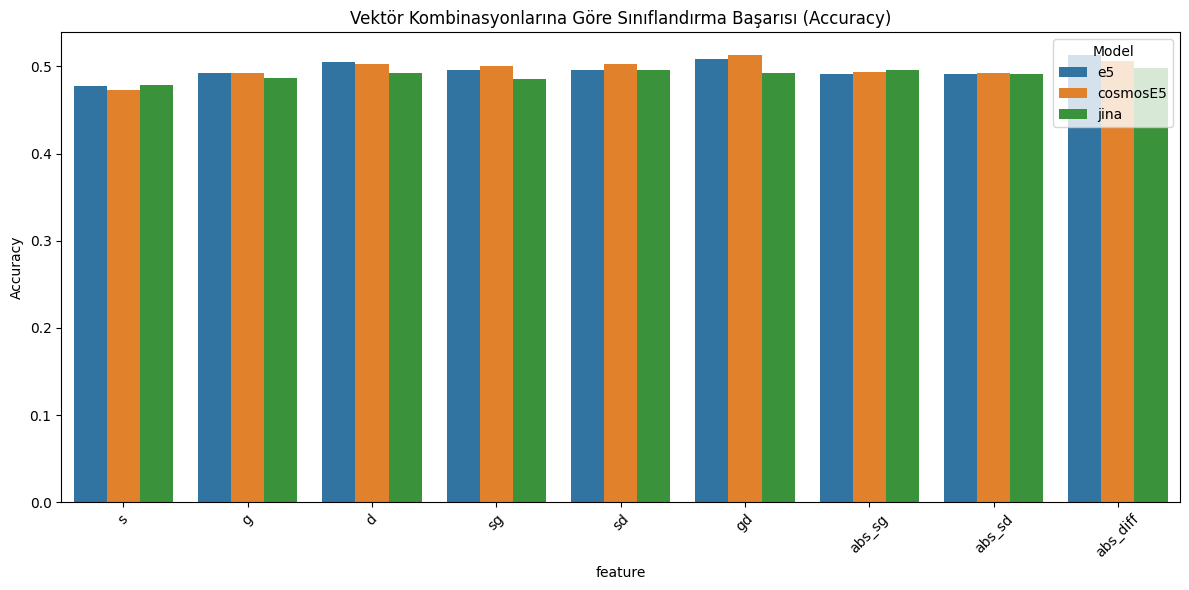

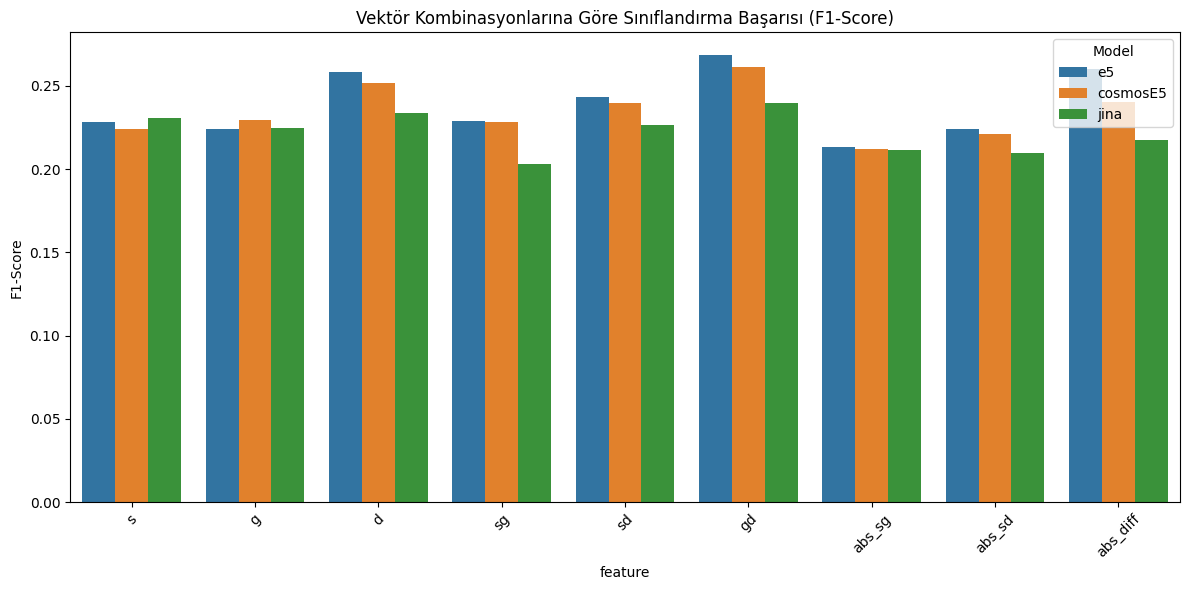

In [9]:


# 4- Sonuçları tablo ve grafik olarak gösterme
res_b_df = pd.DataFrame(results_b)
print("\nSınıflandırma Sonuçları:")
print(res_b_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=res_b_df, x="feature", y="accuracy", hue="model")
plt.title("Vektör Kombinasyonlarına Göre Sınıflandırma Başarısı (Accuracy)")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("classification_accuracy.png")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=res_b_df, x="feature", y="f1_score", hue="model")
plt.title("Vektör Kombinasyonlarına Göre Sınıflandırma Başarısı (F1-Score)")
plt.xticks(rotation=45)
plt.ylabel("F1-Score")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("classification_f1.png")
plt.show()